✅All files loaded succesfully!

Train shape: (3000888, 6)
Test shape: (28512, 5)
Holidays shape: (350, 6)
Stores shape: (54, 5)
Oil shape: (1218, 2)


Train columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

First 5 rows of train
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

Data types in train:
id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

Missing values in train:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
✅ Date columns converted to datetime format.

Train date data types:

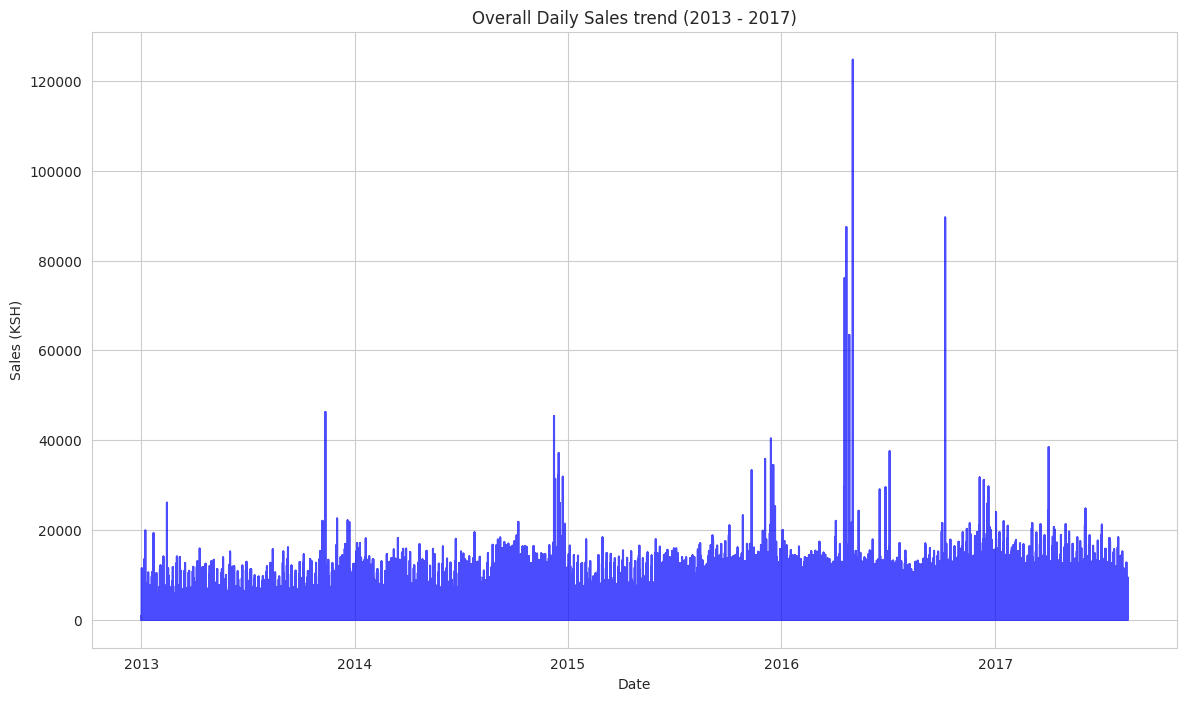

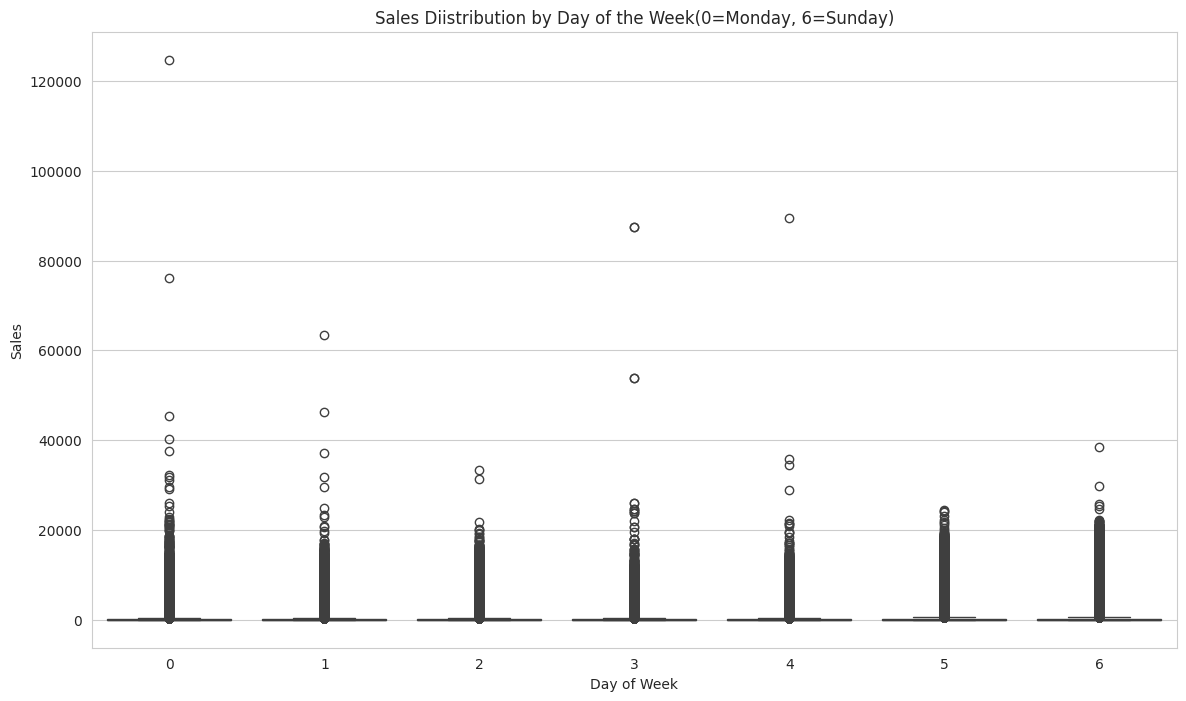

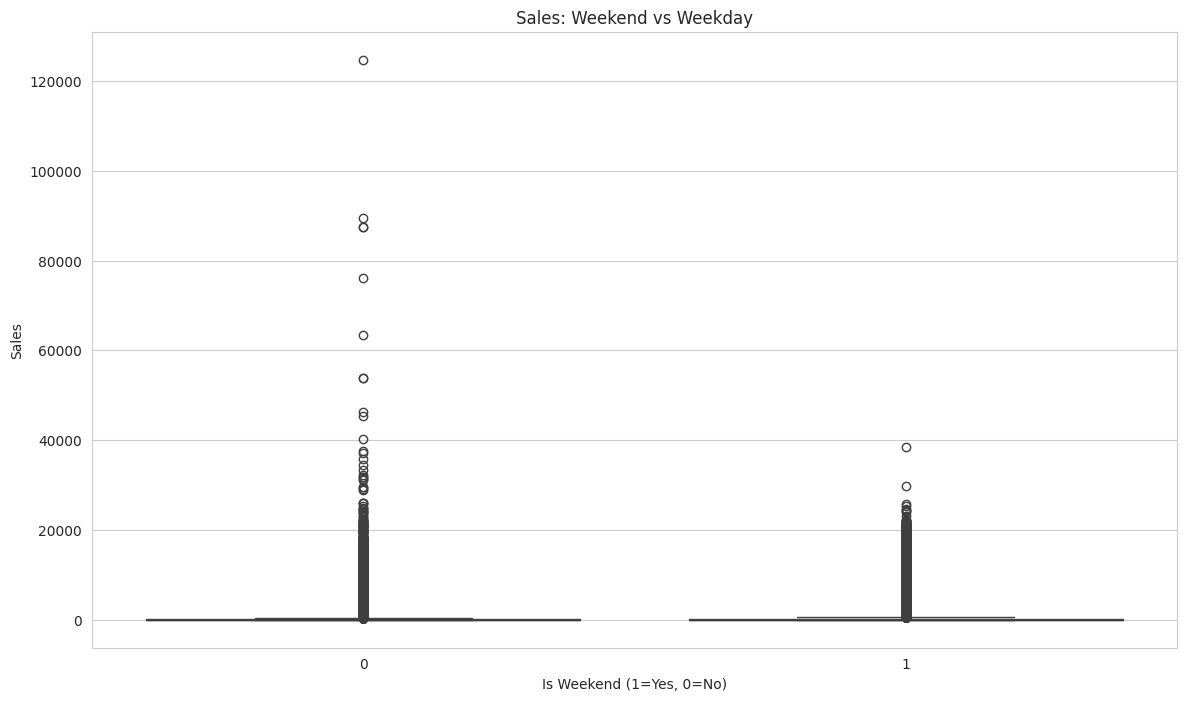

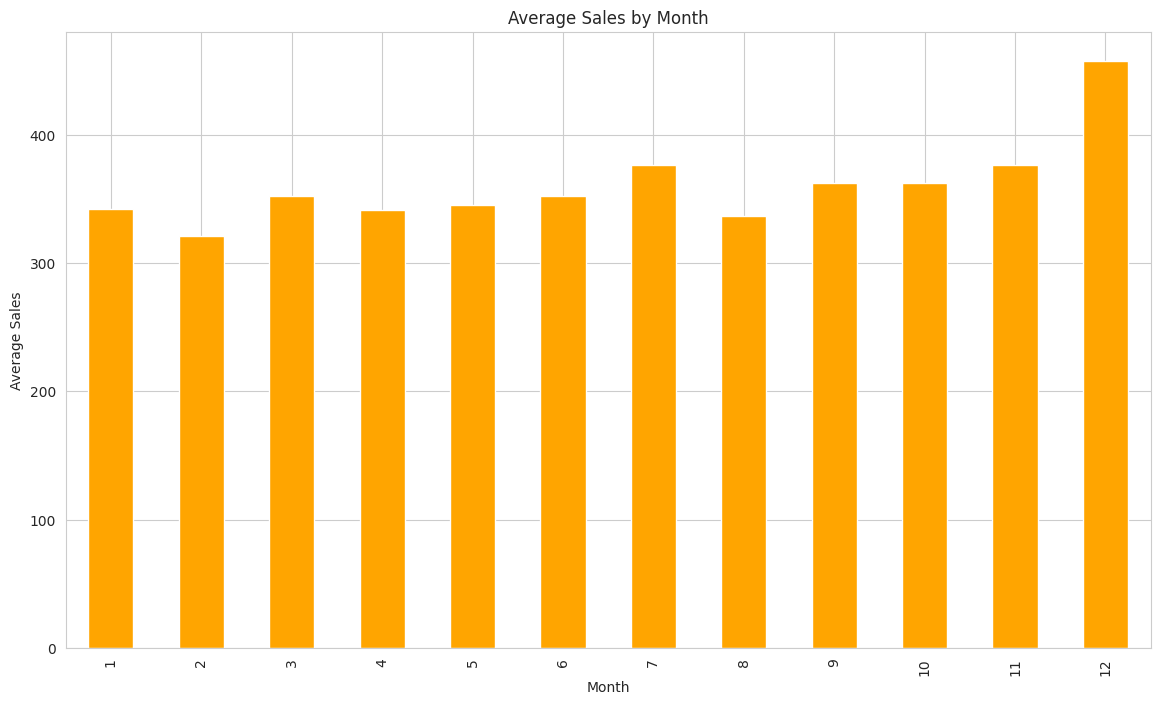

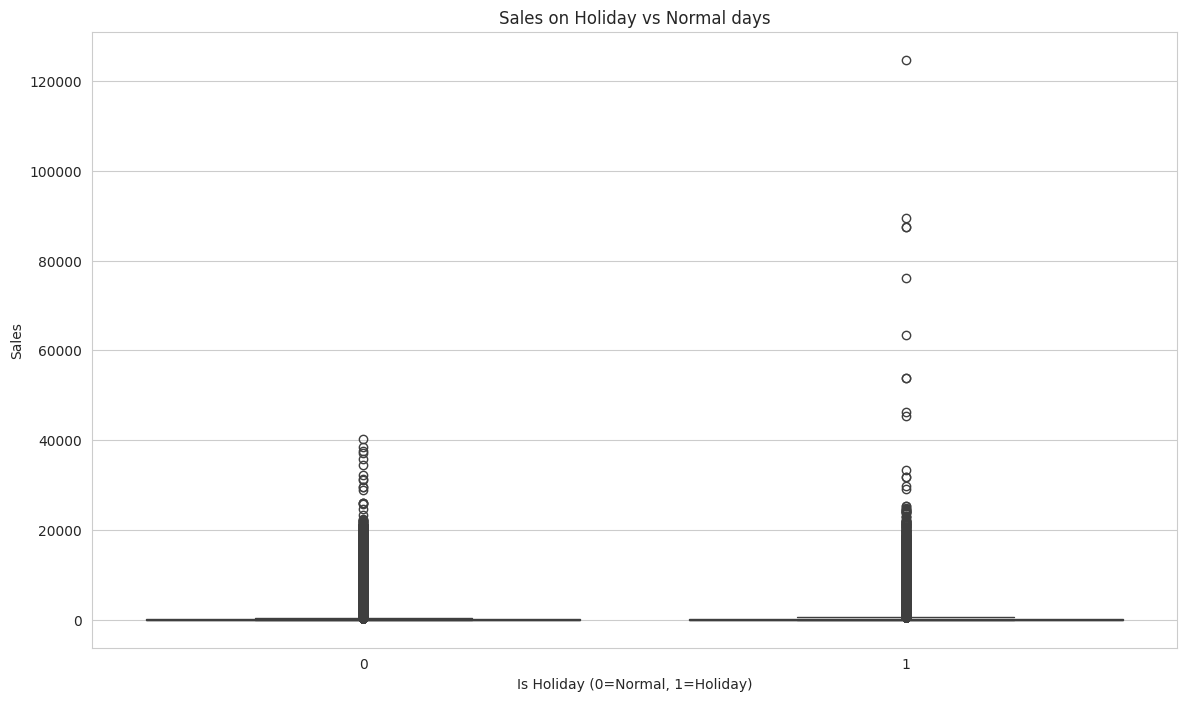

✅ Basic EDA completed!
Total days in Dataset 3054348
Average daily sales: 359.02
Minimum sales : 0.00 | Maximum sales: 124717.00
===== Step1: Simple Stationarity Check (Mean and Variance split) =====

Mean of first half : 489120.44
Mean of second half : 813224.87
Variance of first half : 34469312730.85
Variance of second half : 65881705028.15


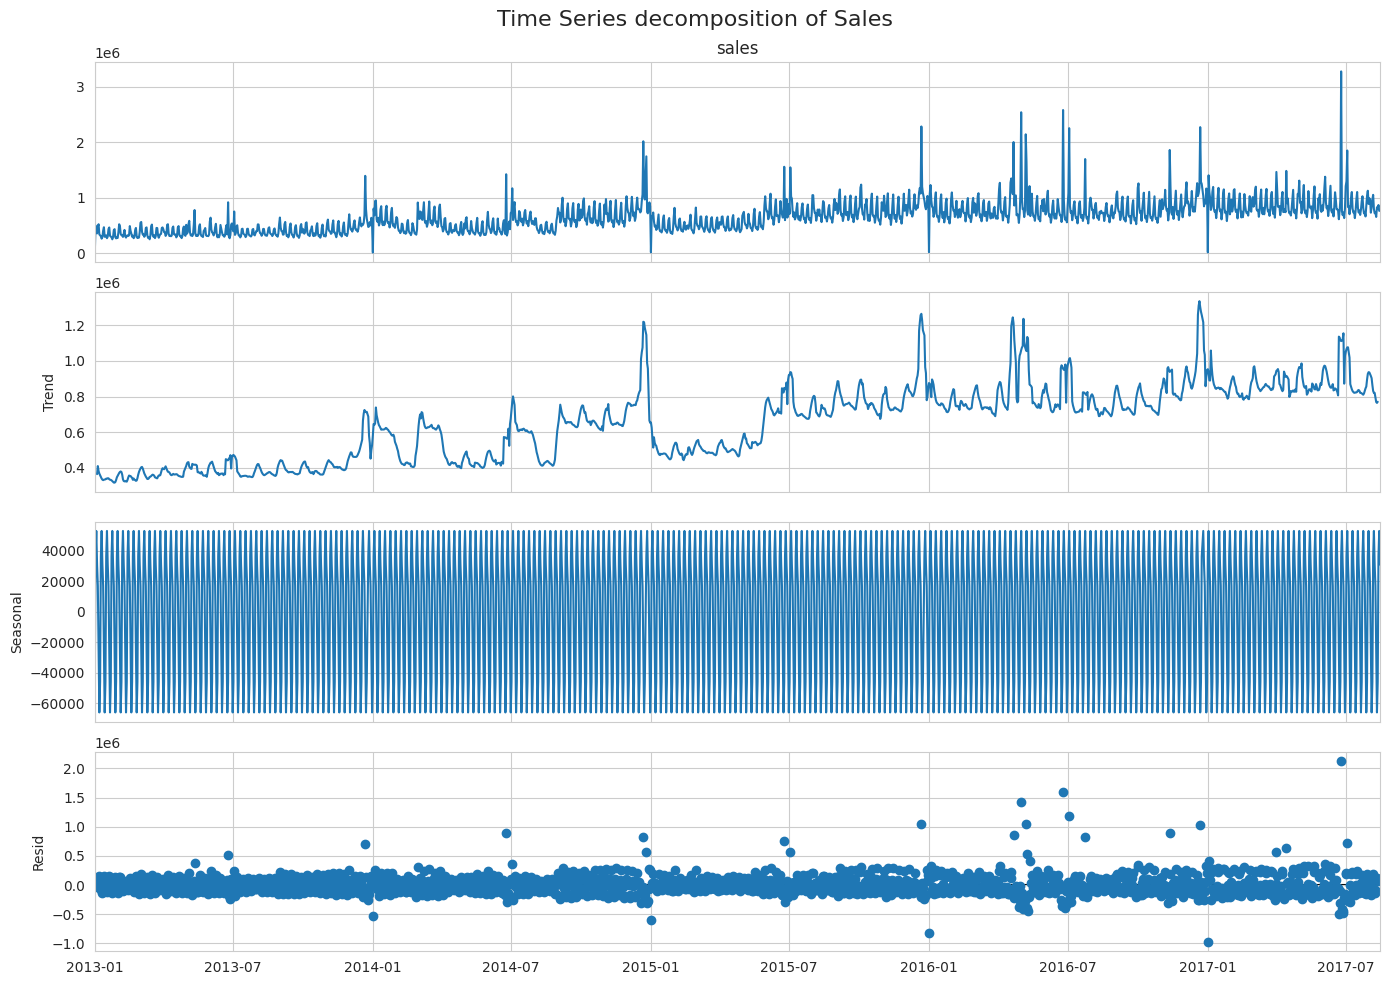


✅ Decomposition completed!
You should now see 4 plots:
1. Observed (original sales)
2. Trend
3. Seasonal
4. Residual (Noise)
Result for Daily Sales (Aggregated):
ADF stattistic: -2.9316
p-value: 0.0418
Critical values:
	1%: -3.4343
	5%: -2.8633
	10%: -2.5677
✅ Conclusion: The series is STATIONARY (p-value <= 0.05)

Summary of what we have so far :
Total unique days analyzed: 1,684
Strong weakly seasonality: Yes (from decomposition)
Long-term trend: Increasing
Data prepared for Prophet:
          ds              y
0 2013-01-01    2511.618999
1 2013-01-02  496092.417944
2 2013-01-03  361461.231124
3 2013-01-04  354459.677093
4 2013-01-05  477350.121229
Prophet_df shape : (1684, 2)


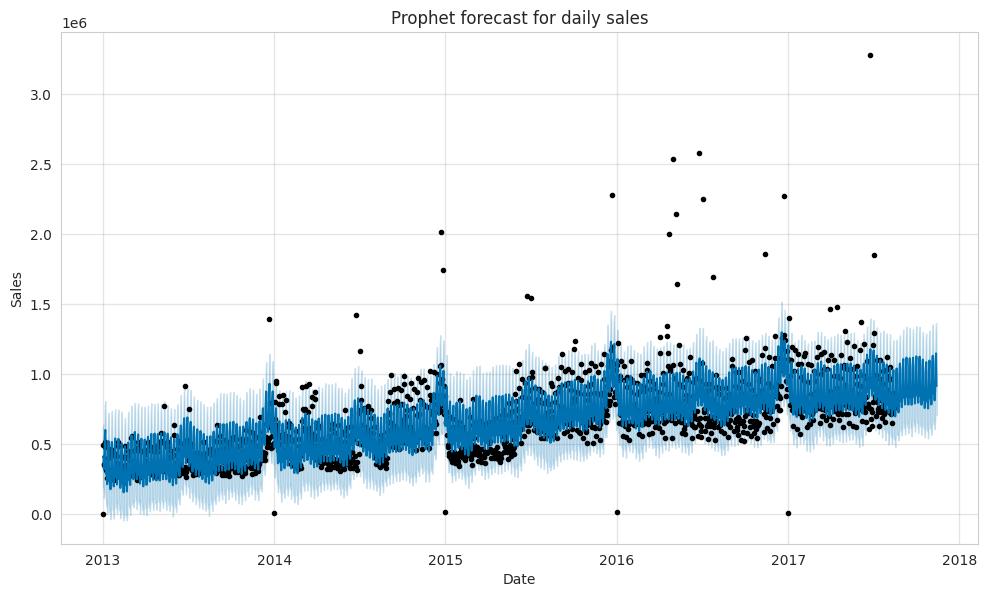

✅ Prophet model has been fitted and forecast generated!
Number of holiday events added: 265


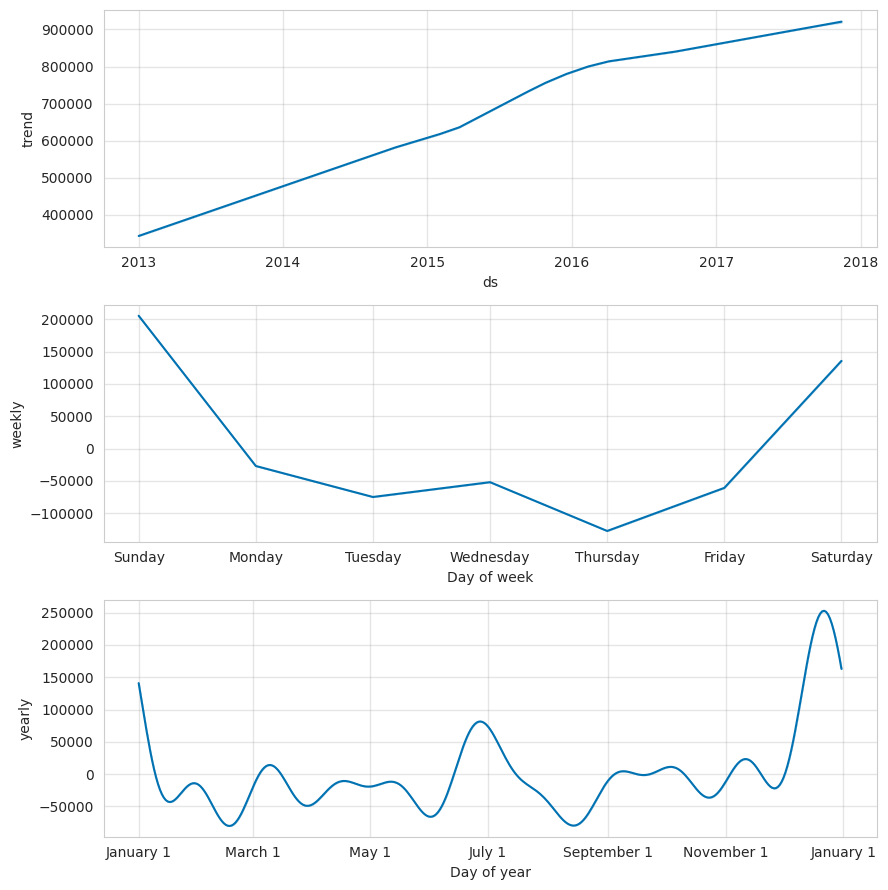

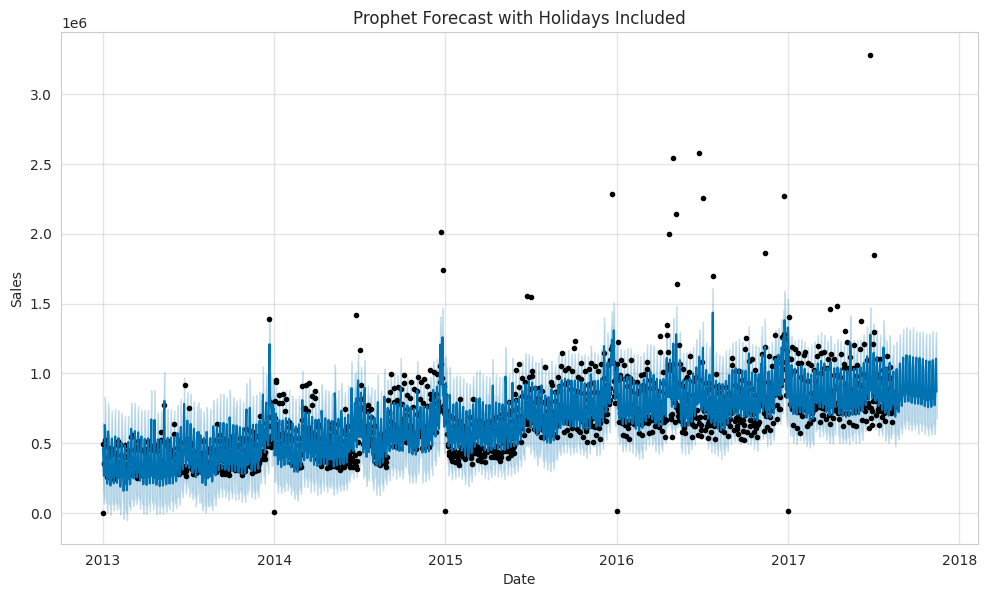

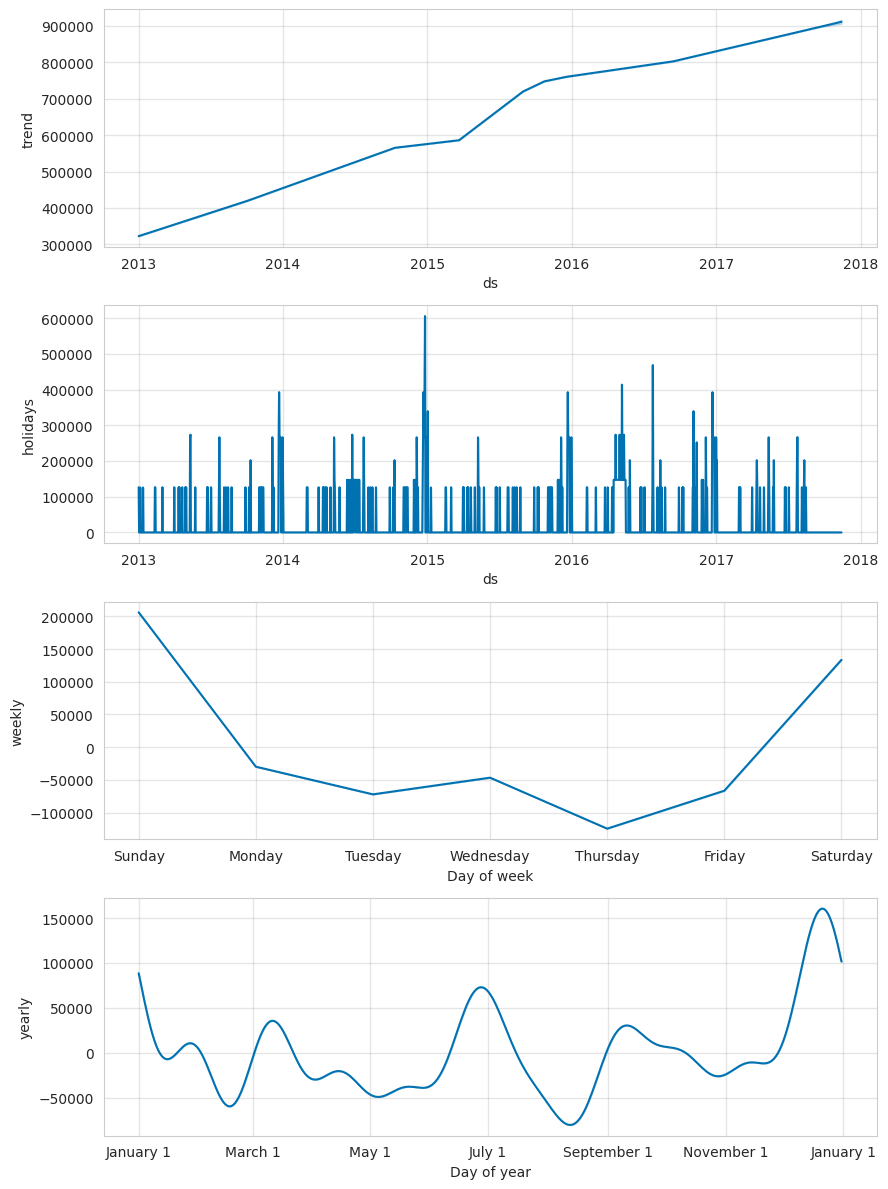

Number of holidays added: 265
Oil price data added for 1683 days


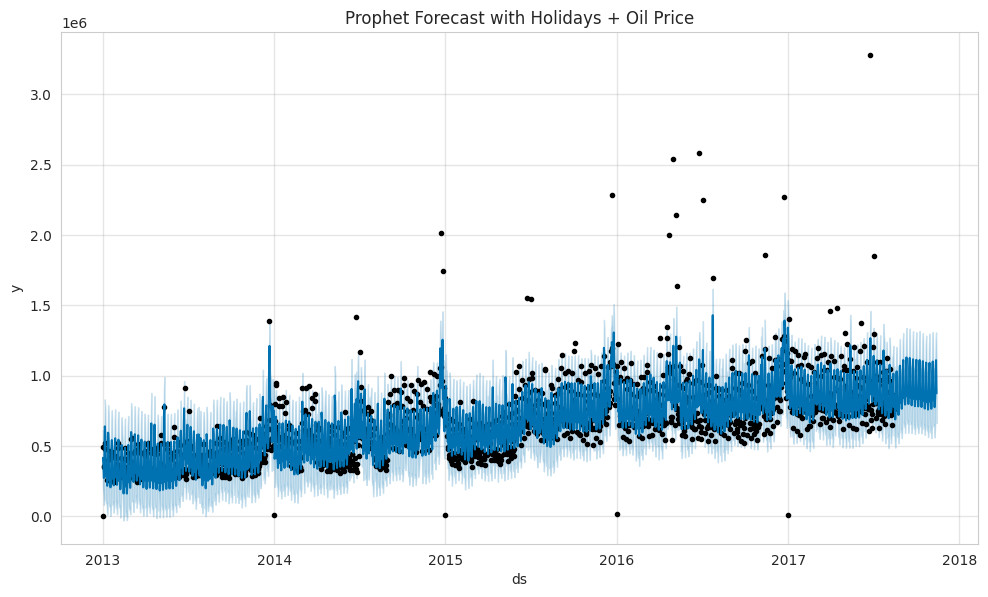

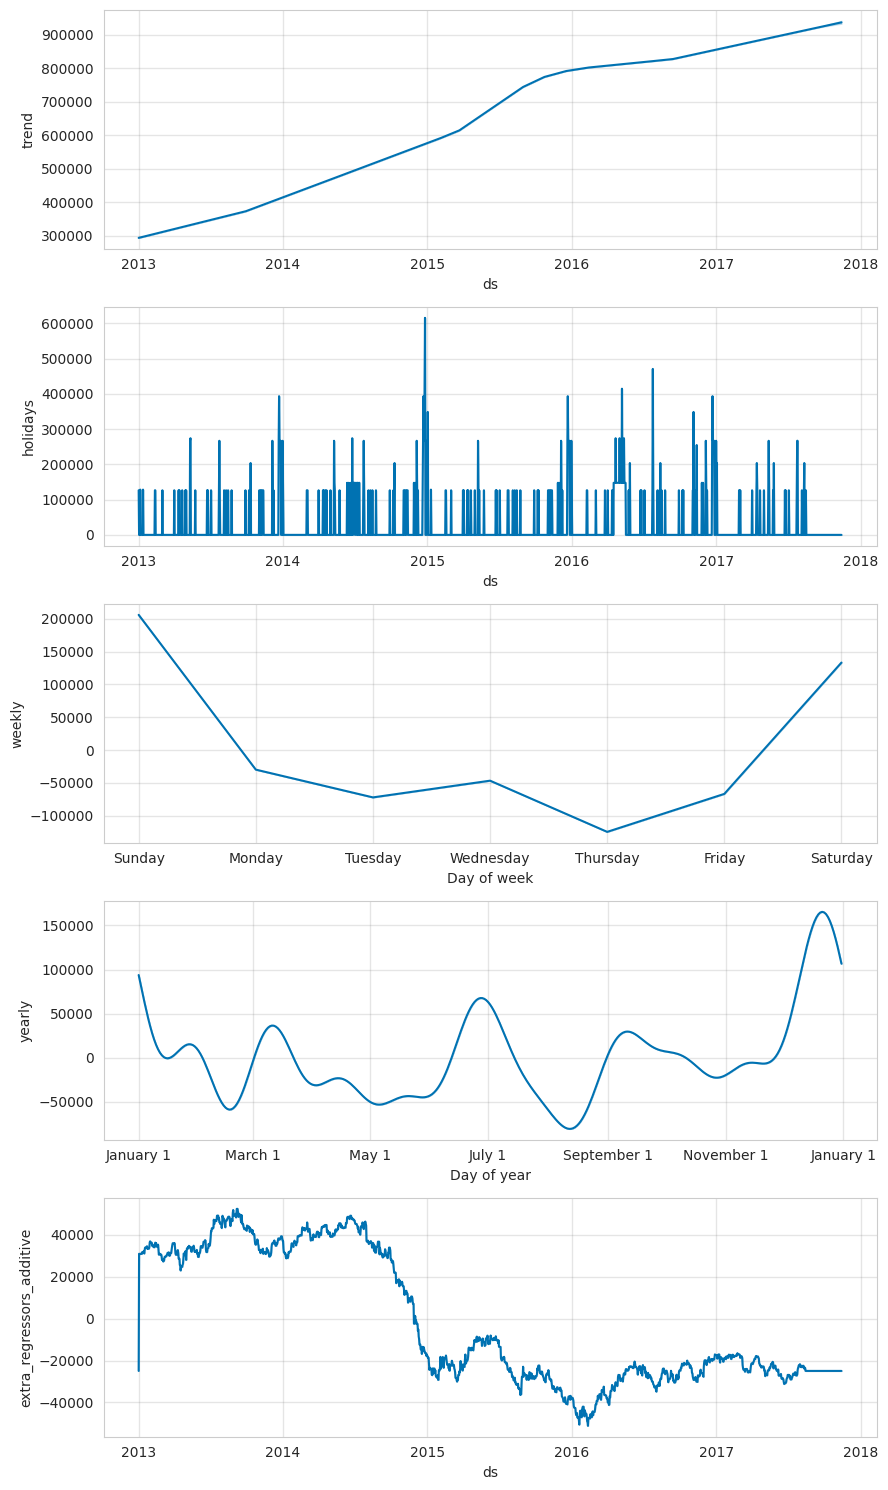

✅ Prophet model with Holidays + Oil Price is ready!
Exogenous variables shape: (1684, 2)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


✅ SARIMA model with holidays + oil price fitted successfully!


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


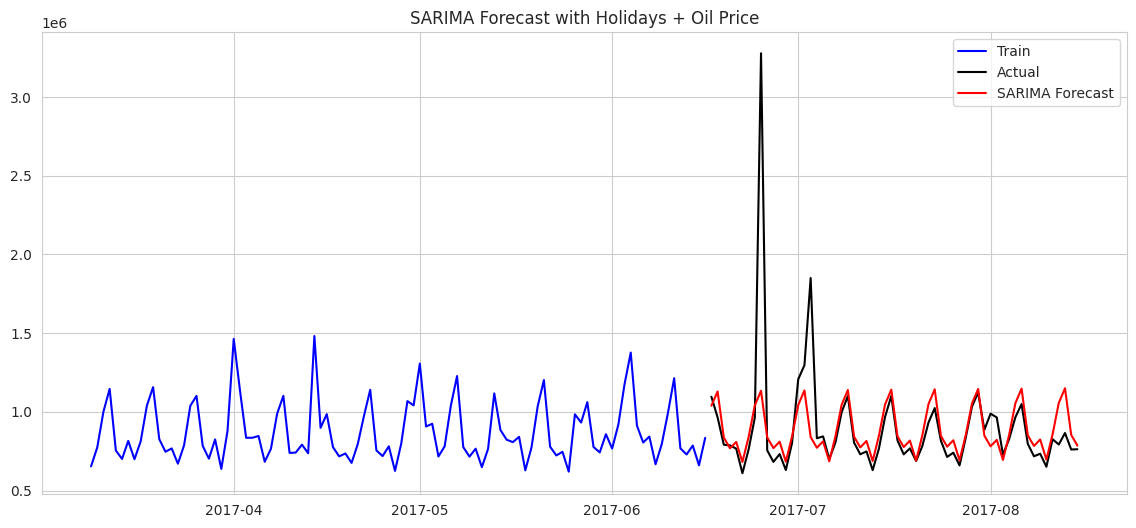


First 10 forecasted values:
1624    1039024.25
1625    1129658.69
1626     837320.23
1627     768385.41
1628     808804.13
1629     681485.14
1630     841057.97
1631    1040976.28
1632    1134128.53
1633     837810.87
Name: predicted_mean, dtype: float64
=== Prophet Next 30 Days Predictions ===
             ds        yhat  yhat_lower  yhat_upper
1684 2017-08-16   765107.60   545934.09   966082.23
1685 2017-08-17   689697.29   489343.67   901792.77
1686 2017-08-18   750713.14   545891.34   953392.78
1687 2017-08-19   954517.80   742373.00  1145666.15
1688 2017-08-20  1031467.72   825370.01  1205181.50
1689 2017-08-21   800381.68   588173.62   999262.29
1690 2017-08-22   763251.57   563141.83   962982.90
1691 2017-08-23   794292.59   592297.11   991800.37
1692 2017-08-24   722189.20   519694.11   922400.90
1693 2017-08-25   786184.26   575395.91   976530.97
1694 2017-08-26   992577.48   780155.56  1178351.69
1695 2017-08-27  1071669.97   889138.95  1262698.49
1696 2017-08-28   842234.38

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
#Load the files
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
holidays=pd.read_csv('holidays_events.csv')
stores=pd.read_csv('stores.csv')
oil=pd.read_csv('oil.csv')
print('✅All files loaded succesfully!\n')
#Basic overview
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Holidays shape: {holidays.shape}")
print(f"Stores shape: {stores.shape}")
print(f"Oil shape: {oil.shape}")
print('\n')
print("Train columns:", train.columns.tolist())
print("\nFirst 5 rows of train")
print(train.head())
print('\nData types in train:')
print(train.dtypes)
print('\nMissing values in train:')
print(train.isnull().sum())
# === IMPORTANT: Convert all date columns to proper datetime ===
train['date'] = pd.to_datetime(train['date'], errors='coerce')
test['date'] = pd.to_datetime(test['date'])
holidays['date'] = pd.to_datetime(holidays['date'])
oil['date'] = pd.to_datetime(oil['date'])
print('✅ Date columns converted to datetime format.\n')
#Quick check
print('Train date data types:',train['date'].dtypes)
print('First 5 dates in train:',train['date'].head().tolist())
print('\nMIssing values summary: ')
print('Train:', train.isnull().sum().sum())
print('Test:', test.isnull().sum().sum())
print('Holidays:', holidays.isnull().sum().sum())
print('Oil:',oil.isnull().sum().sum())
print('Stores:', stores.isnull().sum().sum())
#Merging tables
#Merge stores information
df = train.merge(stores, on='store_nbr', how='left')
#Merge oil prices
df = df.merge(oil, on='date', how='left')
#Merge holidays
df = df.merge(holidays, on='date', how='left')
df = df.set_index('date')
print("✅ Merging completed!")
print(f"Final merged dataset shape: {df.shape}")
print("Columns in the merged table:")
print(df.columns.tolist())
print("\nFirst 5 rows of the merged table:")
print(df.head())
print("\nMissing values after merging:")
print(df.isnull().sum())
#Handling missing values
#Fiil oil price with foward fill(last known price)
df['dcoilwtico'] = df['dcoilwtico'].ffill()
#Fill holiday column with 'No Holiday' where missing
#Rename the holiday 'type' column to avoid conflict
df = df.rename(columns = {'type_x': 'store_type', 'type_y': 'holiday_type'})
print("✅ Column names fixed!")
print("Current columns:")
print(df.columns.tolist())
df['holiday_type'] = df['holiday_type'].fillna('No Holiday')
df['locale'] = df['locale'].fillna('No Holiday')
df['description'] = df['description'].fillna('No Holiday')
print("\nMissing values after cleaning:")
print(df.isnull().sum())
#Create useful features
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)
df['month']= df.index.month
df['year'] = df.index.year
df['is_holiday'] = df['holiday_type'].apply(lambda x: 0 if x== 'No Holiday' else 1)
print("\n✅ Feature engineering completed")
print(f"New columns added:" + str(['day_of_week', 'is_weekend', 'month', 'year', 'is_holiday'])) # Fixed SyntaxWarning
print("\nFirst 5  rows with new features")
print(df.head())
#Exploratory Data Analysis
#Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14,8)
#Overall sales trend
plt.figure()
plt.plot(df.index, df['sales'], color = 'blue', alpha =0.7)
plt.title('Overall Daily Sales trend (2013 - 2017)')
plt.ylabel('Sales (KSH)')
plt.xlabel('Date')
plt.grid(True)
plt.show()
#Sales by day of the week
plt.figure()
sns.boxplot(x = 'day_of_week', y = 'sales', data = df.reset_index()) # Fixed by resetting index
plt.title('Sales Diistribution by Day of the Week(0=Monday, 6=Sunday)')
plt.xlabel('Day of Week')
plt.ylabel('Sales')
plt.show()
#3 Sales on Weekend vs Weekday
plt.figure()
sns.boxplot(x = 'is_weekend', y = 'sales', data=df.reset_index()) # Fixed by resetting index
plt.title('Sales: Weekend vs Weekday')
plt.xlabel('Is Weekend (1=Yes, 0=No)')
plt.ylabel('Sales')
plt.show()
#Average sales by month
monthly_sales = df.groupby('month')['sales'].mean()
plt.figure()
monthly_sales.plot(kind = 'bar', color = 'orange')
plt.title('Average Sales by Month')
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()
#%:Holiday impact
plt.figure()
sns.boxplot(x = 'is_holiday', y = "sales", data=df.reset_index()) # Fixed by resetting index
plt.title('Sales on Holiday vs Normal days')
plt.xlabel("Is Holiday (0=Normal, 1=Holiday)")
plt.ylabel("Sales")
plt.show()
print("✅ Basic EDA completed!")
print(f"Total days in Dataset {len(df)}")
print(f"Average daily sales: {df['sales'].mean():.2f}") # Fixed f-string syntax
print(f"Minimum sales : {df['sales'].min():.2f} | Maximum sales: {df['sales'].max():.2f}") # Fixed f-string syntax and corrected column name
#Stationarity check + Time Series Decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
#Make sure date is index and we have daily frequency
df = df.sort_index()

# Aggregate sales by day for decomposition as seasonal_decompose expects unique time points
daily_sales = df.groupby(df.index)['sales'].sum()

##Stationarity check (Visual + Basic)
print("===== Step1: Simple Stationarity Check (Mean and Variance split) =====\n")
mid_point = len(daily_sales)//2 # Use aggregated daily_sales
print(f"Mean of first half : {daily_sales[:mid_point].mean():.2f}")
print(f"Mean of second half : {daily_sales[mid_point:].mean():.2f}")
print(f"Variance of first half : {daily_sales[:mid_point].var():.2f}")
print(f"Variance of second half : {daily_sales[mid_point:].var():.2f}")
#Full Decomposition (Additive model)
decomposition = seasonal_decompose(daily_sales, model = 'additive', period = 7) # Fixed to use 'sales' and aggregated data
#PLot the Decomposition
fig = decomposition.plot()
fig.set_size_inches(14,10)
plt.suptitle('Time Series decomposition of Sales',fontsize = 16) # Corrected fontsize parameter
plt.tight_layout()
plt.show()
print("\n✅ Decomposition completed!")
print("You should now see 4 plots:")
print("1. Observed (original sales)")
print("2. Trend")
print("3. Seasonal")
print("4. Residual (Noise)")
#Checking for Stationarity (ADF-test)
from statsmodels.tsa.stattools import adfuller
def adf_test(series,title =''):
 result = adfuller(series, autolag = 'AIC')
 print(f'Result for {title}:')
 print(f'ADF stattistic: {result[0]:.4f}')
 print(f'p-value: {result[1]:.4f}')
 print('Critical values:')
 for key, value in result[4].items():
  print(f'\t{key}: {value:.4f}')
 if result[1] <= 0.05:
  print("✅ Conclusion: The series is STATIONARY (p-value <= 0.05)")
 else:
  print('❌ Conclusion: The series is NON-STATIONARY (p-value > 0.05)')
#Run ADF test on the aggregated daily sales
adf_test(daily_sales,title = "Daily Sales (Aggregated)")
print("\n" + "="* 60)
print("Summary of what we have so far :")
print(f"Total unique days analyzed: {len(daily_sales):,}")
print(f"Strong weakly seasonality: Yes (from decomposition)")
print(f"Long-term trend: {'Increasing' if daily_sales.mean() > 1000 else 'Stable'}")
from prophet import Prophet
#Prepare data for prophet (needs columns'ds' and 'y')
prophet_df = daily_sales.reset_index()
prophet_df.columns = ['ds', 'y']
print('Data prepared for Prophet:')
print(prophet_df.head())
print('Prophet_df shape :',prophet_df.shape)
#Create and fit the model
model = Prophet(yearly_seasonality = True, weekly_seasonality = True, daily_seasonality =False, seasonality_mode ='additive',seasonality_prior_scale = 10,changepoint_prior_scale = 0.05)
model.fit(prophet_df)
#Create future dataframe for next 60 days
future = model.make_future_dataframe(periods =90, freq = 'D')
#Make predictions
forecast = model.predict(future)
#Plot the forecast
fig1 = model.plot(forecast)
plt.title("Prophet forecast for daily sales")
plt.xlabel('Date')
plt.ylabel("Sales")
plt.show()
#Plot the components (Trend + Weekly + yearly)
fig2 = model.plot_components(forecast)
print("✅ Prophet model has been fitted and forecast generated!")

#Best improved prophet code with Holidays:
# Prepare data
prophet_df = daily_sales.reset_index()
prophet_df.columns = ['ds', 'y']
#Prepare Holidays for Prophet
#Get unique holiday dates and their types from the original dataframe
holidays_df = df[df['holiday_type'] != 'No Holiday'].reset_index()[['date', 'holiday_type']].drop_duplicates()
holidays_df = holidays_df.rename(columns= {'date' : 'ds', "holiday_type" : 'holiday'})
print(f"Number of holiday events added: {len(holidays_df)}")
#Create and configure the Prophet model
model =Prophet(yearly_seasonality = True, weekly_seasonality = True, daily_seasonality =False, seasonality_mode ='additive',seasonality_prior_scale = 10,changepoint_prior_scale = 0.05, holidays=holidays_df)
#Add the holidays to the model
#model.add_holidays(holidays_df) # This line is removed
#Fit the model
model.fit(prophet_df)
#Create future dates and predict
future = model.make_future_dataframe(periods=90, freq= 'D')
forecast = model.predict(future)
#Plot results
fig3=model.plot(forecast)
plt.title('Prophet Forecast with Holidays Included')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

#Updated prophet code with Oil prices + Holidays
# 1. Prepare main data
prophet_df = daily_sales.reset_index()
prophet_df.columns = ['ds', 'y']
# 2. Add oil price as regressor (we need to aggregate oil to daily level too)
# Since oil is already daily, we can merge it
oil_daily = df.groupby(df.index)['dcoilwtico'].mean()   # take mean if there are duplicates
oil_daily = oil_daily.reset_index()
oil_daily.columns = ['ds', 'oil_price']
# Merge oil into prophet_df
prophet_df = prophet_df.merge(oil_daily, on='ds', how='left')
# Fill NaNs in 'oil_price' before fitting the model
prophet_df['oil_price'] = prophet_df['oil_price'].ffill().bfill()

# 3. Prepare holidays
holidays_df = df[df['holiday_type'] != 'No Holiday'].reset_index()[['date', 'holiday_type']].drop_duplicates()
holidays_df = holidays_df.rename(columns={'date': 'ds', 'holiday_type': 'holiday'})

print(f"Number of holidays added: {len(holidays_df)}")
print(f"Oil price data added for {oil_daily['oil_price'].notna().sum()} days")

# 4. Create Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    seasonality_prior_scale=10,
    changepoint_prior_scale=0.05,
    holidays=holidays_df # Holidays passed directly in constructor
)

# Add holidays
# model.add_holidays(holidays_df) # This line is removed
# Add oil price as regressor
model.add_regressor('oil_price')
# 5. Fit the model
model.fit(prophet_df)
# 6. Future dataframe with oil price
future = model.make_future_dataframe(periods=90)
# We need to add future oil prices. For simplicity, we'll forward-fill the last known oil price
last_oil = prophet_df['oil_price'].iloc[-1]
future = future.merge(oil_daily, on='ds', how='left')
future['oil_price'] = future['oil_price'].fillna(last_oil)
# Predict
forecast = model.predict(future)
# Plot
fig1 = model.plot(forecast)
plt.title('Prophet Forecast with Holidays + Oil Price')
plt.show()
fig2 = model.plot_components(forecast)
plt.show()
print("✅ Prophet model with Holidays + Oil Price is ready!")

from statsmodels.tsa.statespace.sarimax import SARIMAX
# 1. Prepare the target (daily sales)
daily_sales = daily_sales.sort_index()
# 2. Prepare exogenous variables (oil + holidays)
# Oil price (already daily)
exog = df.groupby(df.index)['dcoilwtico'].mean().sort_index()
exog = exog.rename('oil_price')
# Create holiday dummy (1 if holiday, 0 otherwise)
holiday_dummy = df.groupby(df.index)['is_holiday'].max().sort_index()  # 1 if any holiday on that day
# Combine into one exogenous DataFrame
exogenous = pd.concat([exog, holiday_dummy], axis=1)
exogenous.columns = ['oil_price', 'is_holiday']
# Align with daily_sales
exogenous = exogenous.reindex(daily_sales.index)
# Ensure no NaNs in exogenous variables
exogenous['oil_price'] = exogenous['oil_price'].ffill().bfill()

print(f"Exogenous variables shape: {exogenous.shape}")
# 3. Train-test split
train = daily_sales.iloc[:-60]
test = daily_sales.iloc[-60:]
exog_train = exogenous.iloc[:-60]
exog_test = exogenous.iloc[-60:]
# 4. Fit SARIMA with exogenous variables
sarima_model = SARIMAX(
    train,
    exog=exog_train,
    order=(2, 1, 2),           # (p, d, q)
    seasonal_order=(1, 1, 1, 7), # (P, D, Q, m) - weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print("✅ SARIMA model with holidays + oil price fitted successfully!")
# 5. Forecast next 60 days
# For future, we need to provide future exogenous values
# For simplicity, use last known oil price and assume no holidays in future (or add them if known)
future_exog = pd.DataFrame(
    {
        'oil_price': [exog_train['oil_price'].iloc[-1]] * 60,
        'is_holiday': [0] * 60   # assume no holidays for now
    }, index=test.index
)

sarima_forecast = sarima_fit.forecast(steps=60, exog=future_exog)
# 6. Plot comparison
plt.figure(figsize=(14, 6))
plt.plot(train.index[-100:], train.iloc[-100:], label='Train', color='blue')
plt.plot(test.index, test, label='Actual', color='black')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', color='red')
plt.title('SARIMA Forecast with Holidays + Oil Price')
plt.legend()
plt.show()
# Print some forecast values
print("\nFirst 10 forecasted values:")
print(sarima_forecast.head(10).round(2))

# Prophet Future Predictions
future_predictions_prophet = forecast[forecast['ds'] > prophet_df['ds'].max()][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
print("=== Prophet Next 30 Days Predictions ===")
print(future_predictions_prophet.head(30).round(2))
# Save for later
future_predictions_prophet.to_csv('prophet_forecast_final.csv', index=False)
print("Saved as prophet_forecast_final.csv")

# SARIMA Future Predictions
sarima_future = pd.DataFrame({
    'ds': test.index[:30],                    # First 30 days of test period
    'yhat': sarima_forecast[:30]
})
print("\n=== SARIMA Next 30 Days Predictions ===")
print(sarima_future.round(2))
# Save for later
sarima_future.to_csv('sarima_forecast_final.csv', index=False)
print("Saved as sarima_forecast_final.csv")

comparison = pd.DataFrame({
    'Date': future_predictions_prophet['ds'].head(14),
    'Prophet_Prediction': future_predictions_prophet['yhat'].head(14).round(2),
    'SARIMA_Prediction': sarima_future['yhat'].head(14).round(2)
})
print("\n=== Model Comparison - First 14 Future Days ===")
print(comparison)